**SMOTE(Synthetic Minority Oversampling Technique)**

SMOTE is a technique used in machine learning to address imbalanced datasets where the minority class has significantly fewer instances than the majority class. SMOTE involves generating synthetic instances of the minority class by interpolating between existing instances.

In [1]:
from sklearn.datasets import make_classification # Importing make_classification to generate a synthetic dataset for classification problems

In [2]:
# Generate a synthetic (artificial) dataset
x, y = make_classification(
    n_samples = 1000,         # Total number of samples (rows) = 1000
    n_features = 2,           # Number of input features (independent variables) = 2
    n_redundant = 0,          # No redundant (duplicate or correlated) features
    n_clusters_per_class = 1, # Each class will have only 1 cluster of points
    weights = [0.90],         # Class imbalance: 90% samples in class 0, 10% in class 1
    random_state = 45        # Set seed for reproducibility (same random data each time)
)

# x → Feature matrix (independent variables)
# y → Target vector (dependent variable / labels)


In [3]:
x.shape

(1000, 2)

In [4]:
y.shape

(1000,)

In [5]:
import pandas as pd  # Importing pandas library for data manipulation and analysis

# Convert the feature array (x) into a DataFrame with two columns: 'f1' and 'f2'
df1 = pd.DataFrame(x, columns=['f1', 'f2'])

# Convert the target array (y) into a separate DataFrame with one column: 'target'
df2 = pd.DataFrame(y, columns=['target'])

# Combine (merge) both DataFrames horizontally (side by side)
# axis=1 means concatenation along the columns
final_df = pd.concat([df1, df2], axis=1)

# final_df now contains all features (f1, f2) and the target variable in one table


In [6]:
df1.head()

,f1,f2
0,-1.044254,1.383536
1,-0.481652,-1.359175
2,-0.116454,-1.768159
3,-1.778332,-0.023301
4,-1.145796,-0.891281


In [7]:
df2.head()

,target
0,1
1,0
2,0
3,0
4,0


In [8]:
final_df.head()  # Display the first few rows of the final DataFrame

,f1,f2,target
0,-1.044254,1.383536,1
1,-0.481652,-1.359175,0
2,-0.116454,-1.768159,0
3,-1.778332,-0.023301,0
4,-1.145796,-0.891281,0


In [9]:
df1.shape, df2.shape

((1000, 2), (1000, 1))

In [10]:
df2.value_counts()

target
0         901
1          99
Name: count, dtype: int64

In [11]:
final_df.shape

(1000, 3)

# 🔹 Note:
# We can create any number of independent features (f1, f2, f3, ... fN)
# depending on the problem and the dataset.
# However, there is usually only ONE dependent/target column (y)
# because the model is designed to predict a single output value or category
# based on the given input features.

In [12]:
final_df.head()

,f1,f2,target
0,-1.044254,1.383536,1
1,-0.481652,-1.359175,0
2,-0.116454,-1.768159,0
3,-1.778332,-0.023301,0
4,-1.145796,-0.891281,0


In [13]:
final_df['target'].value_counts()

target
0    901
1     99
Name: count, dtype: int64

<Axes: xlabel='f1', ylabel='f2'>

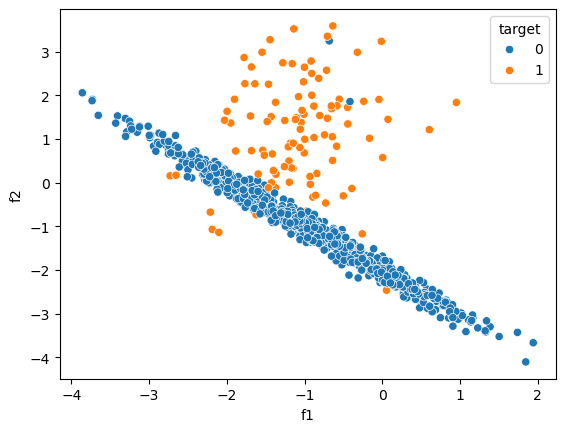

In [14]:
import seaborn as sns
sns.scatterplot(x=final_df['f1'],y=final_df['f2'],hue = final_df['target'])

In [15]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [16]:
from imblearn.over_sampling import SMOTE

In [17]:
# Create an instance of the SMOTE class
# SMOTE generates synthetic (artificial) samples for the minority class
# to balance the dataset, instead of simply duplicating existing samples
oversample = SMOTE()

# Apply SMOTE to the dataset
# fit_resample() takes independent features (X) and the dependent target (y)
# and returns a new balanced version of both
x_resampled, y_resampled = oversample.fit_resample(final_df[['f1', 'f2']], final_df['target'])

# After this step:
# - 'x' contains the resampled independent features
# - 'y' contains the resampled target labels
# Both now have an equal number of samples for each class (0 and 1)

# In short:
# SMOTE helps solve the problem of **imbalanced datasets** (e.g., 90% class 0 and 10% class 1)
# by creating new synthetic data points for the minority class
# → resulting in a balanced dataset that improves model performance.


In [18]:
x_resampled.shape

(1802, 2)

In [19]:
y_resampled.shape

(1802,)

In [20]:
y_resampled.value_counts()

target
1    901
0    901
Name: count, dtype: int64

In [21]:
df1 = pd.DataFrame(x_resampled,columns= ['f1','f2'])
df2 = pd.DataFrame(y_resampled,columns = ['target'])
oversample_df = pd.concat([df1,df2], axis = 1)

In [22]:
oversample_df

,f1,f2,target
0,-1.044254,1.383536,1
1,-0.481652,-1.359175,0
2,-0.116454,-1.768159,0
3,-1.778332,-0.023301,0
4,-1.145796,-0.891281,0
...,...,...,...
1797,-1.098158,3.510505,1
1798,-0.723299,-0.460915,1
1799,0.669565,1.714509,1
1800,-0.904303,-0.116841,1


In [23]:
oversample_df.shape

(1802, 3)

<Axes: xlabel='f1', ylabel='f2'>

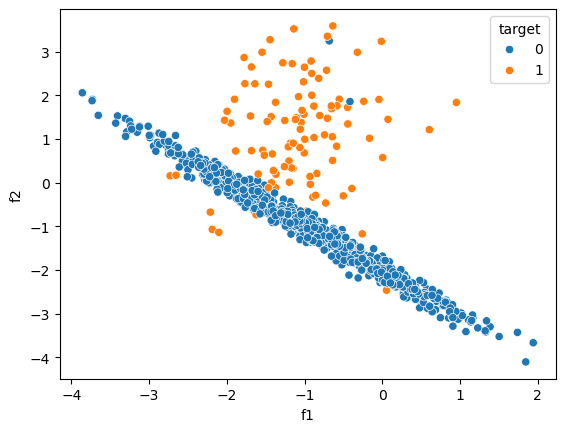

In [24]:
sns.scatterplot(x=final_df['f1'],y=final_df['f2'],hue = final_df['target'])


<Axes: xlabel='f1', ylabel='f2'>

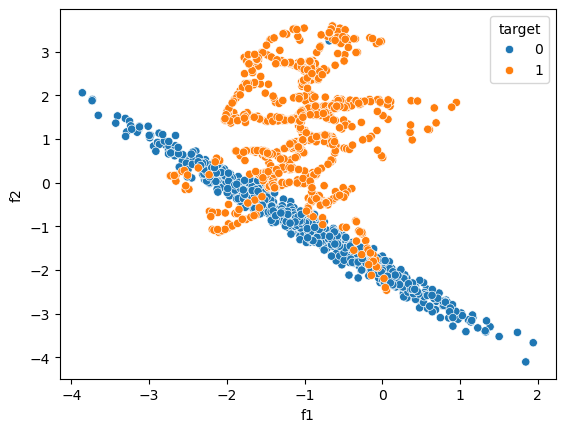

In [25]:
import seaborn as sns
sns.scatterplot(x=oversample_df['f1'],y=oversample_df['f2'],hue = oversample_df['target'])